# Sleep Data — Visualisation

Welcome! In this notebook we will:
1. Load a dataset about sleep and health
2. Look at what's inside it
3. Make some simple charts to understand the data


## Step 1: Import our tools
We need two libraries:
- `pandas` — for loading and working with data (like Excel, but in Python)
- `matplotlib` — for making charts
- `seaborn` — for making better charts

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Step 2: Load the data
We read the CSV file into a **DataFrame** — think of it as a table with rows and columns.

In [4]:
df = pd.read_csv('data/sleep_health_data.csv')


## Chart 1: How long do people sleep?
A **histogram** shows how often values appear. Here we look at sleep duration.

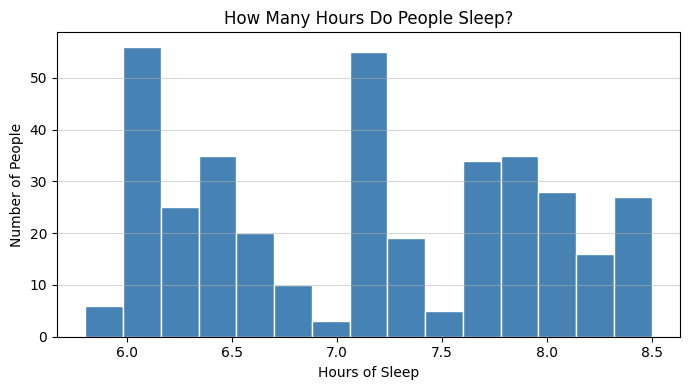

In [5]:
plt.figure(figsize=(7, 4))
plt.hist(df['Sleep Duration'], bins=15, color='steelblue', edgecolor='white')
plt.title('How Many Hours Do People Sleep?')
plt.xlabel('Hours of Sleep')
plt.ylabel('Number of People')
plt.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.show()

## Chart 2: Does more stress mean less sleep?
A **scatter plot** shows the relationship between two numbers. Let's see if stress and sleep are connected.

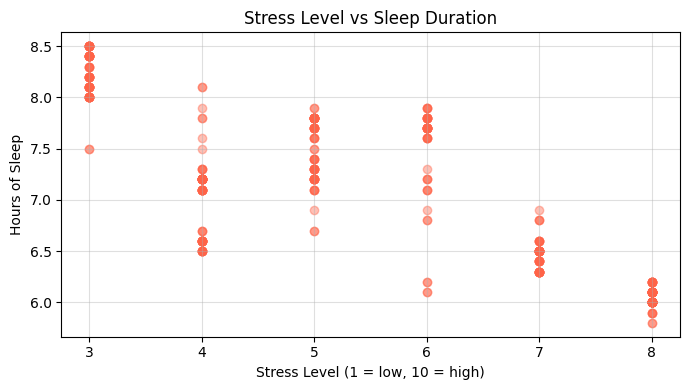

In [6]:
plt.figure(figsize=(7, 4))
plt.scatter(df['Stress Level'], 
            df['Sleep Duration'], color='tomato', alpha=0.4)
plt.title('Stress Level vs Sleep Duration')
plt.xlabel('Stress Level (1 = low, 10 = high)')
plt.ylabel('Hours of Sleep')
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

## Chart 3: How common is each sleep disorder?
A **bar chart** counts how many people fall into each category.

In [ ]:
disorder_counts = df['Sleep Disorder'].value_counts()
plt.figure(figsize=(6, 4))
plt.bar(disorder_counts.index, 
        disorder_counts.values, 
        color=['mediumseagreen', 'salmon', 'mediumpurple'], 
        edgecolor='white')
plt.title('How Many People Have Each Sleep Disorder?')
plt.xlabel('Sleep Disorder')
plt.ylabel('Number of People')
plt.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.show()

## Chart 4: Does physical activity improve sleep quality?
Let's see if people who exercise more tend to sleep better.

In [ ]:
plt.figure(figsize=(7, 4))
plt.scatter(df['Physical Activity Level'], df['Quality of Sleep'], color='mediumorchid', alpha=0.4)
plt.title('Physical Activity vs Sleep Quality')
plt.xlabel('Physical Activity Level')
plt.ylabel('Sleep Quality (1 = bad, 10 = great)')
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

## Chart 5: Sleep quality by BMI category
A **box plot** shows the spread of values for different groups. The line in the middle is the average.

In [ ]:
bmi_groups = [df[df['BMI Category'] == bmi]['Quality of Sleep'] for bmi in df['BMI Category'].unique()]
bmi_labels = list(df['BMI Category'].unique())

plt.figure(figsize=(7, 4))
plt.boxplot(bmi_groups, labels=bmi_labels, patch_artist=True,
            boxprops=dict(facecolor='lightskyblue', color='steelblue'),
            medianprops=dict(color='red', linewidth=2))
plt.title('Sleep Quality by BMI Category')
plt.xlabel('BMI Category')
plt.ylabel('Sleep Quality')
plt.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.show()

## Part 2: Seaborn Charts
Now let's use **seaborn** — it makes beautiful charts with very short code.
Seaborn is great for comparing groups and spotting patterns quickly.

## Seaborn Chart 1: Sleep duration by disorder (Box Plot)
A seaborn **boxplot** is much easier to make than a matplotlib one — and it automatically colours each group!

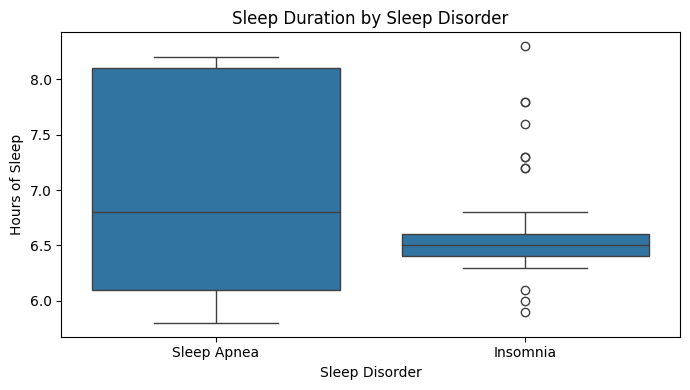

In [9]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='Sleep Disorder', y='Sleep Duration')
plt.title('Sleep Duration by Sleep Disorder')
plt.xlabel('Sleep Disorder')
plt.ylabel('Hours of Sleep')
plt.tight_layout()
plt.show()

## Seaborn Chart 2: Stress level by occupation (Bar Chart)
`sns.barplot` automatically calculates the average for each group and adds error bars.

In [ ]:
plt.figure(figsize=(9, 4))
sns.barplot(data=df, x='Occupation', y='Stress Level', palette='coolwarm')
plt.title('Average Stress Level by Occupation')
plt.xlabel('Occupation')
plt.ylabel('Avg Stress Level')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## Seaborn Chart 3: Sleep quality by gender (Violin Plot)
A **violin plot** is like a box plot but also shows the shape of the data — wider means more people at that value.

In [ ]:
plt.figure(figsize=(6, 4))
sns.violinplot(data=df, x='Gender', y='Quality of Sleep', palette='pastel')
plt.title('Sleep Quality: Male vs Female')
plt.xlabel('Gender')
plt.ylabel('Sleep Quality')
plt.tight_layout()
plt.show()

## Seaborn Chart 4: Count of sleep disorders by gender
`sns.countplot` counts rows for us automatically — no need to calculate anything!

In [ ]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='Sleep Disorder', hue='Gender', palette='Set1')
plt.title('Sleep Disorders: How Many Men vs Women?')
plt.xlabel('Sleep Disorder')
plt.ylabel('Count')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

## Seaborn Chart 5: Correlation Heatmap
A **heatmap** shows how strongly each pair of numbers is related.
- A value close to **+1** means they go up together
- A value close to **-1** means when one goes up, the other goes down
- A value close to **0** means no clear relationship

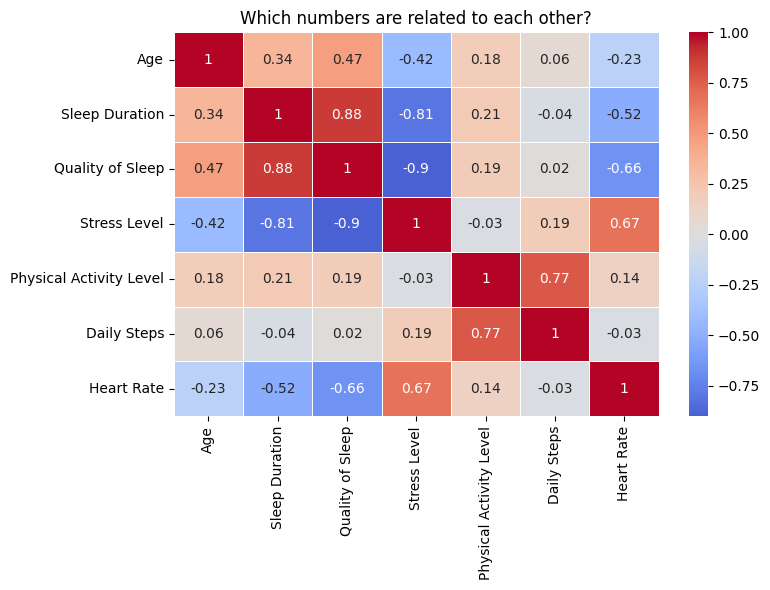

In [11]:
# Pick the numeric columns we care about
num_cols = ['Age', 'Sleep Duration', 'Quality of Sleep', 'Stress Level', 'Physical Activity Level', 'Daily Steps', 'Heart Rate']
corr = df[num_cols].corr().round(2)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Which numbers are related to each other?')
plt.tight_layout()
plt.show()

## What did we learn?

From our charts, we can see:
- Most people sleep between **6 and 8 hours** per night
- **Higher stress** tends to come with **less sleep**
- Most people have **no sleep disorder**, but Insomnia and Sleep Apnea are still common
- People who are **more physically active** tend to have **better sleep quality**
- BMI category can affect how well someone sleeps

---
**Well done for completing the notebook! 🚀**

Try changing the colors or chart types to practice your Python skills!